# Asymmetric Clausius Quarkyonic Diagnostics

This notebook is a diagnostic companion to `asymmetric_clausius_quarkyonic_eos.ipynb`.
It does not modify that workflow. Instead, it focuses on:

- fixed-`y` energy ordering,
- crossing densities between selected `y` branches,
- the quarkyonic onset through `f_{q,\star}`,
- and the location of the `v_s^2` peaks.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path("/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows")
src_path = repo_root / "asymmetric_clausius_fit" / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from asymmetric_clausius_fit import MP, build_quarkyonic_eos_objects, default_rhob_list, default_y_values

pd.set_option("display.precision", 6)

results_dir = repo_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)
output_dir = results_dir / "asymmetric_clausius_quarkyonic_diagnostics"
output_dir.mkdir(parents=True, exist_ok=True)

ACTIVE_TARGET_K0S = [250.0, 280.0, 315.0]
Y_VALUES = default_y_values()

# Skip the nearly-zero density point where the fq minimizer is numerically degenerate.
DIAGNOSTIC_RHOB_LIST = default_rhob_list(n_points=240, low=0.05, high=5.0)

EOS_NINT = 160
FQ_MIN = 1.0e-3
FQ_MAX = 1.0
FQ_ONSET_THRESHOLD = 0.01
TOL = 1.0e-6

colors = ["blue", "deepskyblue", "cyan", "springgreen", "magenta", "purple"]

output_dir


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_diagnostics')

The diagnostic grid starts at `0.05 rho_0` instead of `10^-6 rho_0`.
This avoids the trivial low-density degeneracy where the fixed-`y` minimizer can return `f_q ~ 1` at essentially zero density without affecting the physically relevant region.

In [2]:
fit_csv = results_dir / "asymmetric_clausius_fit_results.csv"
fit_df = pd.read_csv(fit_csv)
fit_df = fit_df[fit_df["target_k0"].isin(ACTIVE_TARGET_K0S)].sort_values("target_k0").reset_index(drop=True)

display(fit_df[["target_k0", "K0", "a_n", "a_pn", "b_n", "b_pn", "c", "J", "L"]])

eos_map = build_quarkyonic_eos_objects(fit_df, target_k0_values=ACTIVE_TARGET_K0S, nint=EOS_NINT)
list(eos_map.keys())


,target_k0,K0,a_n,a_pn,b_n,b_pn,c,J,L
0,250.0,250.000002,259.413733,685.241282,1.316923,2.137819,4.735853,32.5,58.9
1,280.0,280.000000,250.336526,658.488869,1.417423,2.455476,4.114108,32.5,58.9
2,315.0,314.999999,241.580371,631.849247,1.525881,2.761368,3.507371,32.5,58.9


['k0_250', 'k0_280', 'k0_315']

In [3]:
def add_energy_columns(df):
    out = df.copy()
    out["e_over_n_minus_mn"] = out["energy_density"] / out["rhob"] - MP
    return out


def first_crossing_density(df_a, df_b, column="e_over_n_minus_mn"):
    x = df_a["rho_over_rho0"].to_numpy(dtype=float)
    d = df_a[column].to_numpy(dtype=float) - df_b[column].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(d)
    x = x[mask]
    d = d[mask]
    if len(x) < 2:
        return np.nan
    for i in range(len(x) - 1):
        d0 = d[i]
        d1 = d[i + 1]
        if d0 == 0.0:
            return float(x[i])
        if d0 * d1 < 0.0:
            if d1 == d0:
                return float(x[i])
            return float(x[i] - d0 * (x[i + 1] - x[i]) / (d1 - d0))
    return np.nan


def rho_at_max(df, column):
    idx = int(np.nanargmax(df[column].to_numpy(dtype=float)))
    return float(df.iloc[idx]["rho_over_rho0"]), float(df.iloc[idx][column]), float(df.iloc[idx]["fq_star"])


def first_onset_density(df, threshold=FQ_ONSET_THRESHOLD):
    fq = df["fq_star"].to_numpy(dtype=float)
    mask = fq >= threshold
    if not np.any(mask):
        return np.nan
    idx = int(np.argmax(mask))
    return float(df.iloc[idx]["rho_over_rho0"])


fixed_y_results = {}
summary_rows = []
crossing_rows = []

for label, eos in eos_map.items():
    profile_map = {}
    for y in Y_VALUES:
        df = eos.fixed_y_profile(
            DIAGNOSTIC_RHOB_LIST,
            y=float(y),
            fq_min=FQ_MIN,
            fq_max=FQ_MAX,
            tol=TOL,
        )
        profile_map[float(y)] = add_energy_columns(df)

    fixed_y_results[label] = profile_map
    reference_df = profile_map[0.5]

    for y, df in profile_map.items():
        rho_vs2_max, vs2_max, fq_at_peak = rho_at_max(df, "vs2")
        crossing_to_sym = np.nan if y == 0.5 else first_crossing_density(df, reference_df)
        summary_rows.append(
            {
                "label": label,
                "target_k0": float(eos.target_k0),
                "y": float(y),
                "onset_rho_fq_0p01": first_onset_density(df),
                "rho_vs2_max": rho_vs2_max,
                "vs2_max": vs2_max,
                "fq_at_vs2_max": fq_at_peak,
                "crossing_with_y0p5": crossing_to_sym,
            }
        )

    pairs = [(0.0, 0.1), (0.0, 0.5), (0.1, 0.5)]
    for y_left, y_right in pairs:
        crossing_rows.append(
            {
                "label": label,
                "target_k0": float(eos.target_k0),
                "left_y": y_left,
                "right_y": y_right,
                "crossing_rho": first_crossing_density(profile_map[y_left], profile_map[y_right]),
            }
        )

summary_df = pd.DataFrame(summary_rows)
crossing_df = pd.DataFrame(crossing_rows)

summary_csv = output_dir / "fixed_y_diagnostic_summary.csv"
crossing_csv = output_dir / "fixed_y_crossings.csv"

summary_df.to_csv(summary_csv, index=False)
crossing_df.to_csv(crossing_csv, index=False)

display(summary_df)
display(crossing_df)
summary_csv, crossing_csv


,label,target_k0,y,onset_rho_fq_0p01,rho_vs2_max,vs2_max,fq_at_vs2_max,crossing_with_y0p5
0,k0_250,250.0,0.0,3.135983,3.591632,1.146430,0.028554,NaN
1,k0_250,250.0,0.1,2.866736,2.970293,2.534809,0.021486,NaN
2,k0_250,250.0,0.2,2.804603,2.970293,1.789911,0.024471,NaN
3,k0_250,250.0,0.3,2.742469,2.949582,1.457023,0.025197,NaN
4,k0_250,250.0,0.4,2.701046,2.908159,1.280266,0.024372,NaN
5,k0_250,250.0,0.5,2.659623,2.887448,1.169329,0.026085,NaN
6,k0_280,280.0,0.0,2.908159,3.343096,1.108195,0.029953,NaN
7,k0_280,280.0,0.1,2.535356,2.597490,2.629554,0.019835,NaN
8,k0_280,280.0,0.2,2.493933,2.618201,1.808141,0.023869,NaN
9,k0_280,280.0,0.3,2.452510,2.618201,1.423356,0.025432,NaN


,label,target_k0,left_y,right_y,crossing_rho
0,k0_250,250.0,0.0,0.1,3.134533
1,k0_250,250.0,0.0,0.5,NaN
2,k0_250,250.0,0.1,0.5,NaN
3,k0_280,280.0,0.0,0.1,2.724083
4,k0_280,280.0,0.0,0.5,NaN
5,k0_280,280.0,0.1,0.5,NaN
6,k0_315,315.0,0.0,0.1,2.425841
7,k0_315,315.0,0.0,0.5,2.897182
8,k0_315,315.0,0.1,0.5,NaN


(PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_diagnostics/fixed_y_diagnostic_summary.csv'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_diagnostics/fixed_y_crossings.csv'))

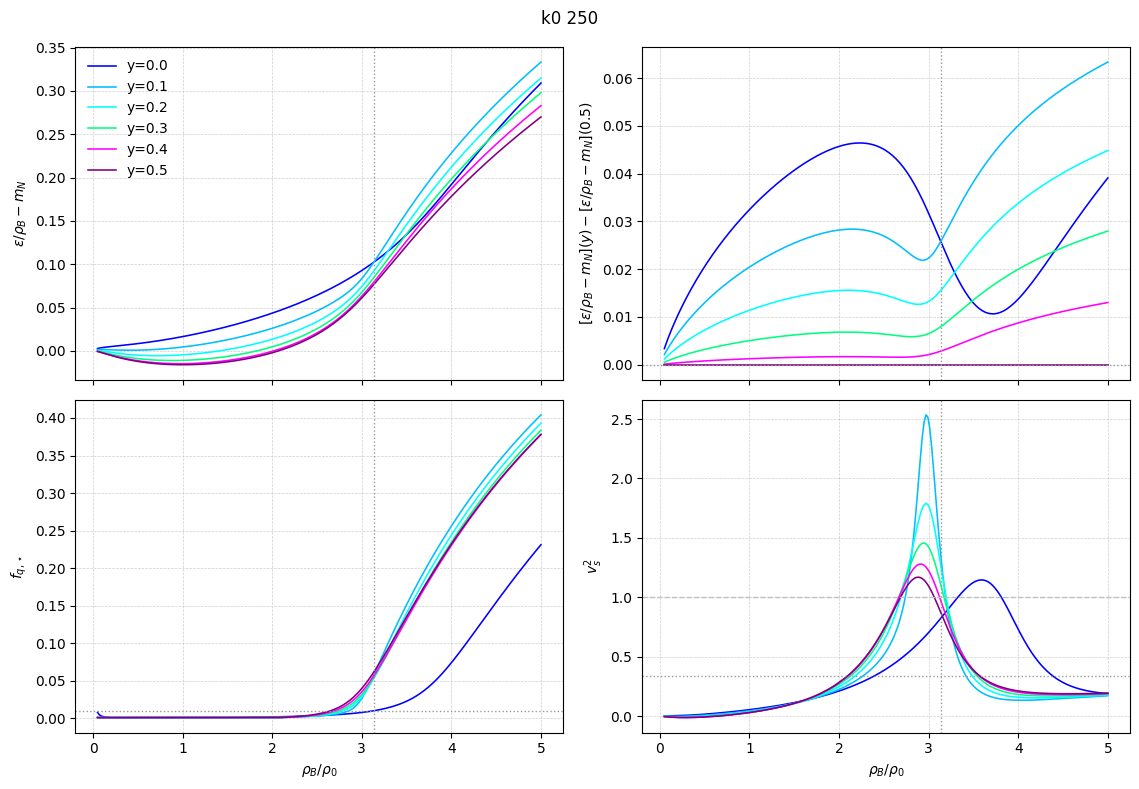

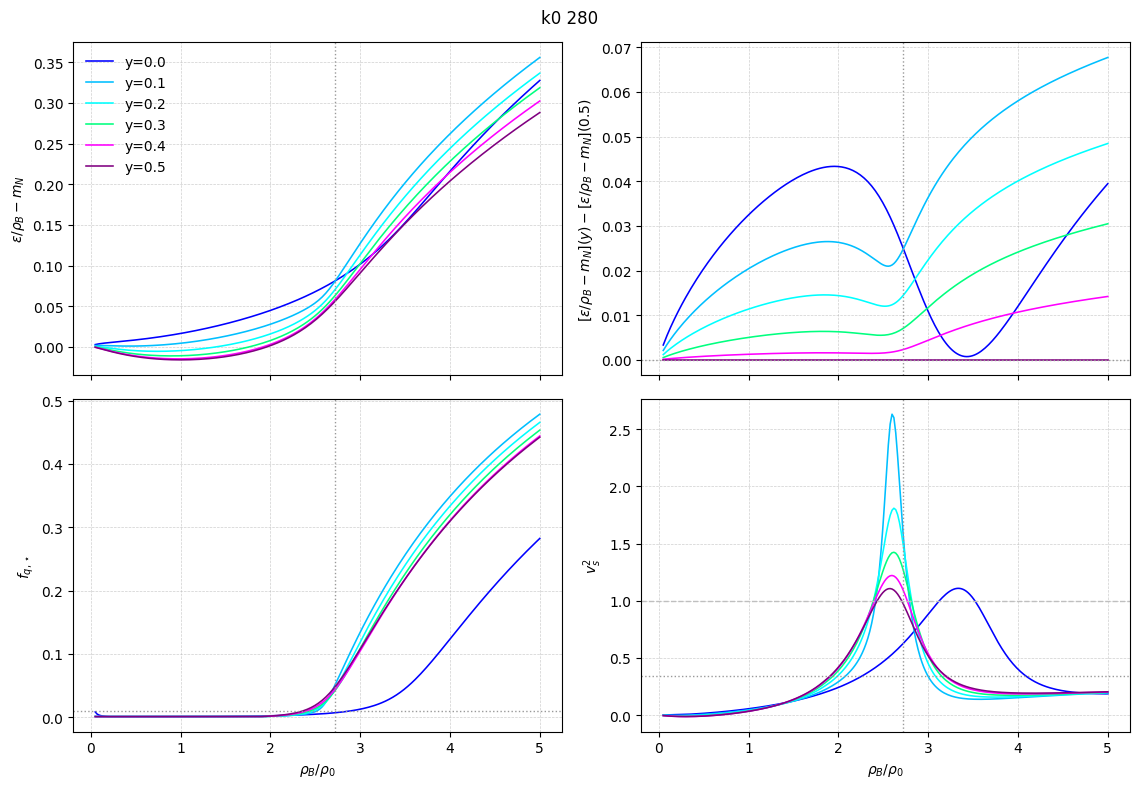

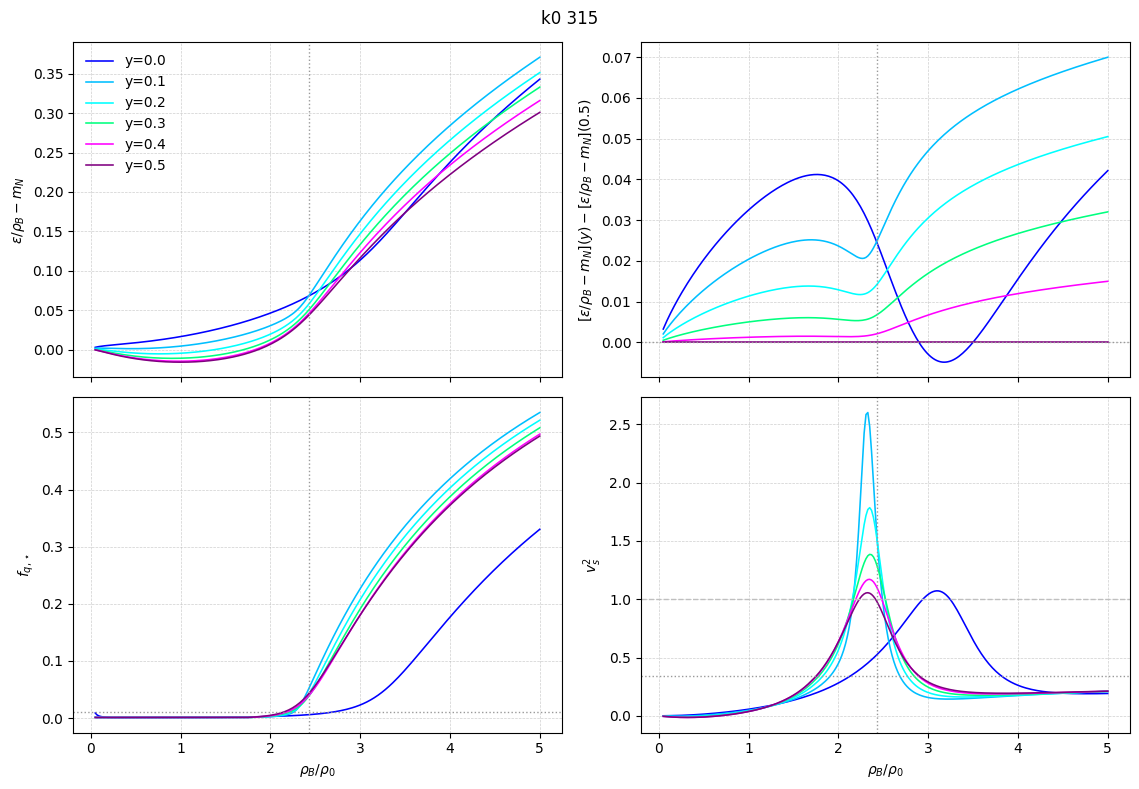

In [4]:
for label, profile_map in fixed_y_results.items():
    reference_df = profile_map[0.5]
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), sharex=True)
    fig.suptitle(label.replace("_", " "))

    for color, y in zip(colors, Y_VALUES):
        df = profile_map[float(y)]
        axes[0, 0].plot(df["rho_over_rho0"], df["e_over_n_minus_mn"], color=color, lw=1.15, label=f"y={y:.1f}")
        axes[0, 1].plot(
            df["rho_over_rho0"],
            df["e_over_n_minus_mn"] - reference_df["e_over_n_minus_mn"],
            color=color,
            lw=1.15,
            label=f"y={y:.1f}",
        )
        axes[1, 0].plot(df["rho_over_rho0"], df["fq_star"], color=color, lw=1.15, label=f"y={y:.1f}")
        axes[1, 1].plot(df["rho_over_rho0"], df["vs2"], color=color, lw=1.15, label=f"y={y:.1f}")

    y0_y01 = first_crossing_density(profile_map[0.0], profile_map[0.1])
    if np.isfinite(y0_y01):
        for ax in axes.ravel():
            ax.axvline(y0_y01, color="0.6", ls=":", lw=1.0)

    axes[0, 0].set_ylabel(r"$\epsilon / \rho_B - m_N$")
    axes[0, 0].legend(frameon=False)

    axes[0, 1].axhline(0.0, color="0.6", ls=":", lw=1.0)
    axes[0, 1].set_ylabel(r"$[\epsilon/\rho_B - m_N](y) - [\epsilon/\rho_B - m_N](0.5)$")

    axes[1, 0].axhline(FQ_ONSET_THRESHOLD, color="0.6", ls=":", lw=1.0)
    axes[1, 0].set_ylabel(r"$f_{q,\star}$")
    axes[1, 0].set_xlabel(r"$\rho_B/\rho_0$")

    axes[1, 1].axhline(0.34, color="0.6", ls=":", lw=1.0)
    axes[1, 1].axhline(1.0, color="0.75", ls="--", lw=1.0)
    axes[1, 1].set_ylabel(r"$v_s^2$")
    axes[1, 1].set_xlabel(r"$\rho_B/\rho_0$")

    for ax in axes.ravel():
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)

    plt.tight_layout()
    plt.show()


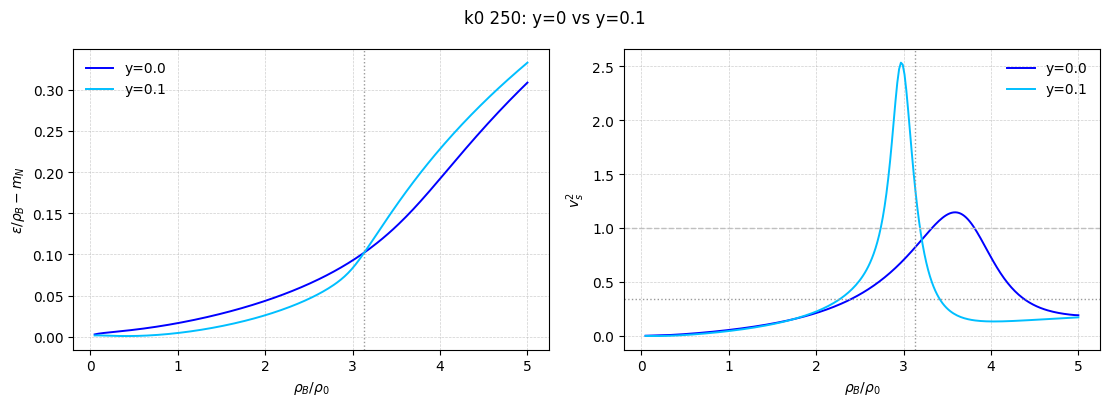

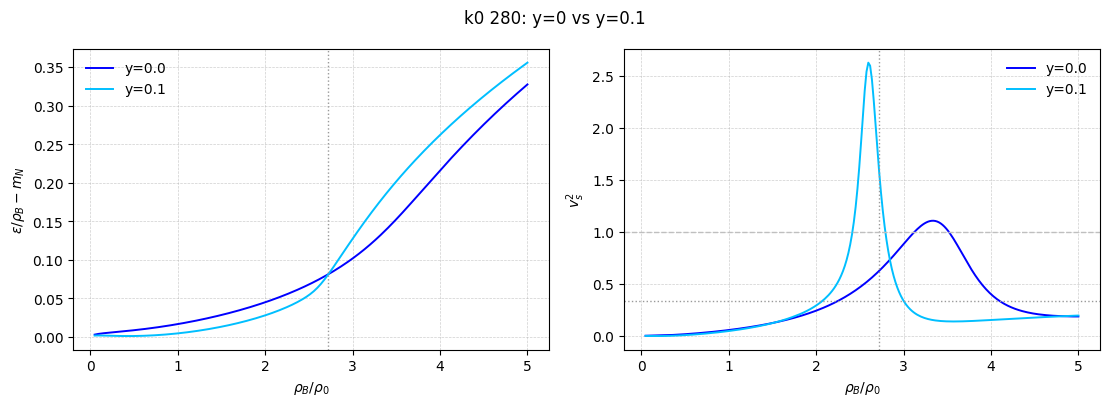

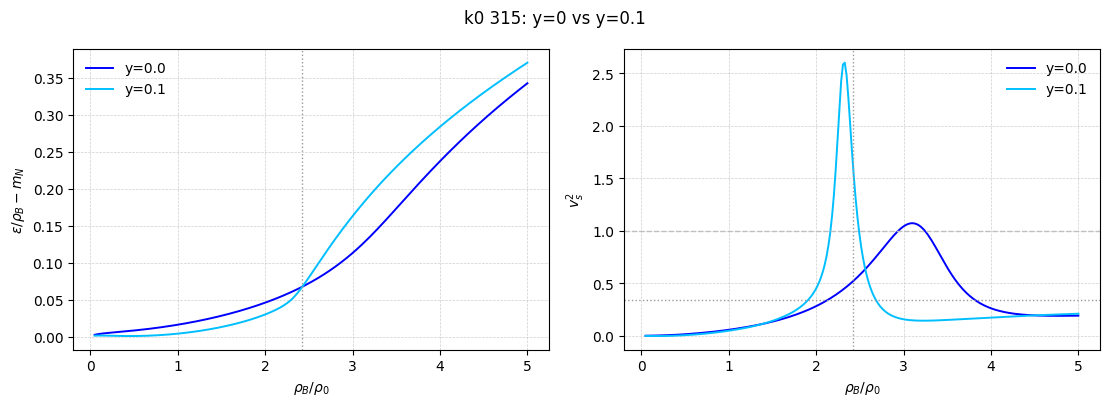

In [5]:
for label, profile_map in fixed_y_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1), sharex=True)
    fig.suptitle(f"{label.replace('_', ' ')}: y=0 vs y=0.1")

    for y, color in [(0.0, 'blue'), (0.1, 'deepskyblue')]:
        df = profile_map[y]
        axes[0].plot(df["rho_over_rho0"], df["e_over_n_minus_mn"], color=color, lw=1.4, label=f"y={y:.1f}")
        axes[1].plot(df["rho_over_rho0"], df["vs2"], color=color, lw=1.4, label=f"y={y:.1f}")

    crossing = first_crossing_density(profile_map[0.0], profile_map[0.1])
    if np.isfinite(crossing):
        for ax in axes:
            ax.axvline(crossing, color="0.6", ls=":", lw=1.0)

    axes[0].set_ylabel(r"$\epsilon / \rho_B - m_N$")
    axes[0].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1].axhline(0.34, color="0.6", ls=":", lw=1.0)
    axes[1].axhline(1.0, color="0.75", ls="--", lw=1.0)
    axes[1].set_ylabel(r"$v_s^2$")
    axes[1].set_xlabel(r"$\rho_B/\rho_0$")

    for ax in axes:
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)
        ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


Suggested reading of the plots:

- If `y=0` stays above `y=0.1` over the full density range, the energy ordering is monotonic in isospin asymmetry.
- If `y=0` crosses below `y=0.1`, inspect whether the crossing happens near the quarkyonic onset in `f_{q,\star}`.
- If the `v_s^2` peak and the `y=0`/`y=0.1` crossing occur in the same density window, the anomaly is likely driven by the onset physics rather than by the low-density calibration alone.
